<a href="https://colab.research.google.com/github/diniarv5/Smart-Agriculture-DLM-Project/blob/main/Data_Lifecycle_Smart_Farming.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import files
files.upload() # Pilih file kaggle.json dari folder Downloads tadi

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"fivediniaredrap","key":"8940883248c7d0b147591c70a848b71f"}'}

In [2]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [5]:
# 1. Download dataset
!kaggle datasets download -d chaitanyagopidesi/smart-agriculture-dataset

# 2. Unzip ke folder data/raw sesuai struktur di halaman 21
!mkdir -p data/raw
!unzip smart-agriculture-dataset.zip -d data/raw

# 3. Cek nama file asli yang ada di dalam folder
import os
print(os.listdir("data/raw"))

Dataset URL: https://www.kaggle.com/datasets/chaitanyagopidesi/smart-agriculture-dataset
License(s): apache-2.0
  0% 0.00/66.1k [00:00<?, ?B/s]
100% 66.1k/66.1k [00:00<00:00, 208MB/s]
Archive:  smart-agriculture-dataset.zip
  inflating: data/raw/cropdata_updated.csv  
['cropdata_updated.csv']


In [7]:
import pandas as pd

# Nama file yang benar hasil unzip adalah 'cropdata_updated.csv'
file_path = 'data/raw/cropdata_updated.csv'

# Memuat data
df = pd.read_csv(file_path)

print("Dataset Berhasil Dimuat!")
display(df.head()) # Menampilkan 5 baris pertama

Dataset Berhasil Dimuat!


,crop ID,soil_type,Seedling Stage,MOI,temp,humidity,result
0,Wheat,Black Soil,Germination,1,25,80.0,1
1,Wheat,Black Soil,Germination,2,26,77.0,1
2,Wheat,Black Soil,Germination,3,27,74.0,1
3,Wheat,Black Soil,Germination,4,28,71.0,1
4,Wheat,Black Soil,Germination,5,29,68.0,1


In [8]:
# Cek data kosong
print("Jumlah data kosong per kolom:")
print(df.isnull().sum())

# Menghapus baris yang memiliki nilai kosong
df_cleaned = df.dropna()

# Menyimpan data bersih ke folder outputs sesuai instruksi tugas
import os
if not os.path.exists('outputs'):
    os.makedirs('outputs')

df_cleaned.to_csv('outputs/cleaned_data.csv', index=False)
print("Data bersih telah disimpan di folder outputs/cleaned_data.csv")

Jumlah data kosong per kolom:
crop ID           0
soil_type         0
Seedling Stage    0
MOI               0
temp              0
humidity          0
result            0
dtype: int64
Data bersih telah disimpan di folder outputs/cleaned_data.csv


In [9]:
# Analisis deskriptif sensor
print("Ringkasan Statistik Sensor IoT:")
display(df_cleaned.describe())

Ringkasan Statistik Sensor IoT:


,MOI,temp,humidity,result
count,16411.000000,16411.000000,16411.000000,16411.000000
mean,43.695387,28.832612,63.487752,0.516178
std,27.160264,9.701465,22.630965,0.621691
min,1.000000,13.000000,15.000000,0.000000
25%,21.000000,20.000000,44.000000,0.000000
50%,41.000000,28.000000,69.200000,0.000000
75%,64.000000,37.000000,84.000000,1.000000
max,100.000000,46.000000,91.000000,2.000000


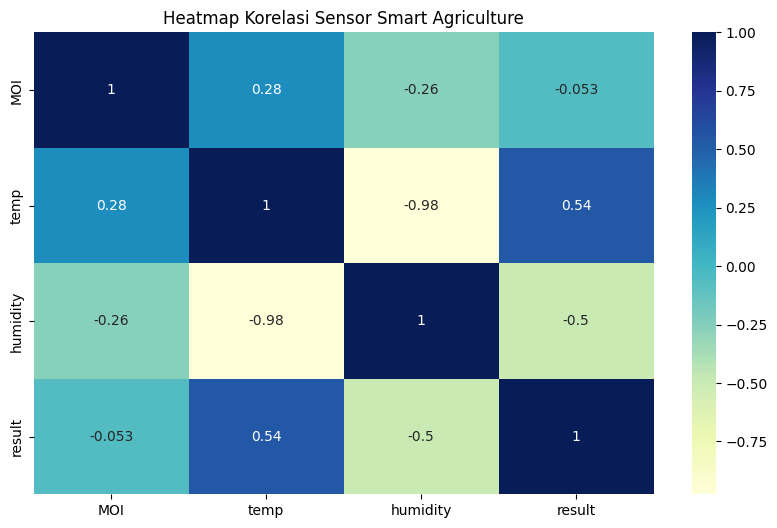

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns
import os

# 1. Pastikan folder output tersedia
if not os.path.exists('outputs'):
    os.makedirs('outputs')

# 2. Hanya ambil kolom numerik untuk korelasi agar tidak error 'Wheat'
numeric_df = df.select_dtypes(include=['float64', 'int64'])

# 3. Visualisasi Heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(numeric_df.corr(), annot=True, cmap='YlGnBu')
plt.title("Heatmap Korelasi Sensor Smart Agriculture")

# 4. Simpan untuk dokumentasi di folder outputs [cite: 132]
plt.savefig('outputs/correlation_heatmap.png')
plt.show()

In [12]:
%%writefile app.py
import streamlit as st
import pandas as pd
import plotly.express as px

st.set_page_config(page_title="Smart Farming Dashboard", layout="wide")
st.title("🌾 Smart Farming Dashboard - Smart Village")

# Load data bersih
df = pd.read_csv('data/raw/cropdata_updated.csv')

# Visualisasi 1: Tren Sensor [cite: 135]
st.subheader("Monitoring Tren Sensor IoT")
sensor_choice = st.selectbox("Pilih Sensor:", ["temperature", "humidity", "ph", "rainfall"])
fig = px.line(df.head(100), y=sensor_choice, title=f"Tren {sensor_choice}")
st.plotly_chart(fig)

# Visualisasi 2: Sistem Peringatan (Alert Threshold) [cite: 135]
st.subheader("Sistem Peringatan Dini")
temp_latest = df['temperature'].iloc[-1]
if temp_latest > 35:
    st.error(f"⚠️ Suhu Terlalu Panas: {temp_latest}°C! Aktifkan penyiram otomatis.")
else:
    st.success(f"✅ Suhu Normal: {temp_latest}°C")

Writing app.py
